In [23]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
from pathlib import Path

import nomad.io.base as loader
import nomad.stop_detection.lachesis as LACHESIS
import nomad.data as data_folder
from nomad.stop_detection.viz import animate_stop_dashboard

In [24]:
from pathlib import Path
import os

print("cwd:", os.getcwd())

repo_root = Path("/Users/anoushkamenon/Desktop/nomad")
print("repo exists:", repo_root.exists())

print("examples exists:", (repo_root / "examples").exists())
print("gc_data_long exists:", (repo_root / "examples" / "gc_data_long").exists())

cwd: /Users/anoushkamenon/Desktop/nomad/nomad/tests
repo exists: True
examples exists: True
gc_data_long exists: True


In [25]:
# load lachesis sample data & generate traj
data_dir = Path(data_folder.__file__).parent
city = gpd.read_parquet(data_dir / 'garden-city-buildings-mercator.parquet')
outer_box = box(*city.total_bounds)

filepath_root = str(repo_root / "examples" / "gc_data_long")
tc = {
    "user_id": "gc_identifier",
    "x": "dev_x",
    "y": "dev_y",
    "timestamp": "unix_ts"
}

users = ['admiring_brattain']

traj = loader.sample_from_file(
    filepath_root,
    format='parquet',
    users=users,
    filters=('date', '==', '2024-01-01'),
    traj_cols=tc
)

print(traj.head())
print(traj.columns)
print(len(traj))

       gc_identifier         dev_x         dev_y     unix_ts         ha  \
0  admiring_brattain -4.265481e+06  4.393146e+06  1704106881  10.702426   
1  admiring_brattain -4.265533e+06  4.393159e+06  1704107003  19.015804   
2  admiring_brattain -4.265477e+06  4.393185e+06  1704107072  24.851835   
3  admiring_brattain -4.265490e+06  4.393156e+06  1704107268  10.181171   
4  admiring_brattain -4.265491e+06  4.393147e+06  1704107349  11.100491   

   tz_offset        date  
0     -14400  2024-01-01  
1     -14400  2024-01-01  
2     -14400  2024-01-01  
3     -14400  2024-01-01  
4     -14400  2024-01-01  
Index(['gc_identifier', 'dev_x', 'dev_y', 'unix_ts', 'ha', 'tz_offset',
       'date'],
      dtype='str')
96


In [26]:
# generate stops
stops = LACHESIS.lachesis(
    traj,
    delta_roam=20,
    dt_max=60,
    dur_min=5,
    complete_output=True,
    keep_col_names=True,
    traj_cols=tc
)

print(stops.head())
print(stops.columns)
print(len(stops))

   cluster             x             y     unix_ts         ha   diameter  \
0        0 -4.265482e+06  4.393153e+06  1704107777  11.006086  14.820705   
1        1 -4.265478e+06  4.393120e+06  1704112028  11.038392  16.458197   
2        2 -4.265482e+06  4.393117e+06  1704112843  12.200451  18.663269   
3        3 -4.265475e+06  4.393110e+06  1704113482   9.792796   8.638411   
4        4 -4.265449e+06  4.393130e+06  1704114942  11.163325  17.188732   

   n_pings  end_timestamp  duration  max_gap      gc_identifier  
0        3     1704108899        18       12  admiring_brattain  
1        6     1704112657        10        3  admiring_brattain  
2        4     1704113143         5        3  admiring_brattain  
3        3     1704113875         6        6  admiring_brattain  
4        6     1704116038        18        7  admiring_brattain  
Index(['cluster', 'x', 'y', 'unix_ts', 'ha', 'diameter', 'n_pings',
       'end_timestamp', 'duration', 'max_gap', 'gc_identifier'],
      dtype='s

In [27]:
# fix timestamp to match anim func
stops_anim = stops.rename(columns={'unix_ts': 'timestamp'}).copy()
traj_anim = traj.rename(columns={'unix_ts': 'timestamp'}).copy()

tc_anim = {
    "user_id": "gc_identifier",
    "x": "dev_x",
    "y": "dev_y",
    "timestamp": "timestamp"
}

animation saved


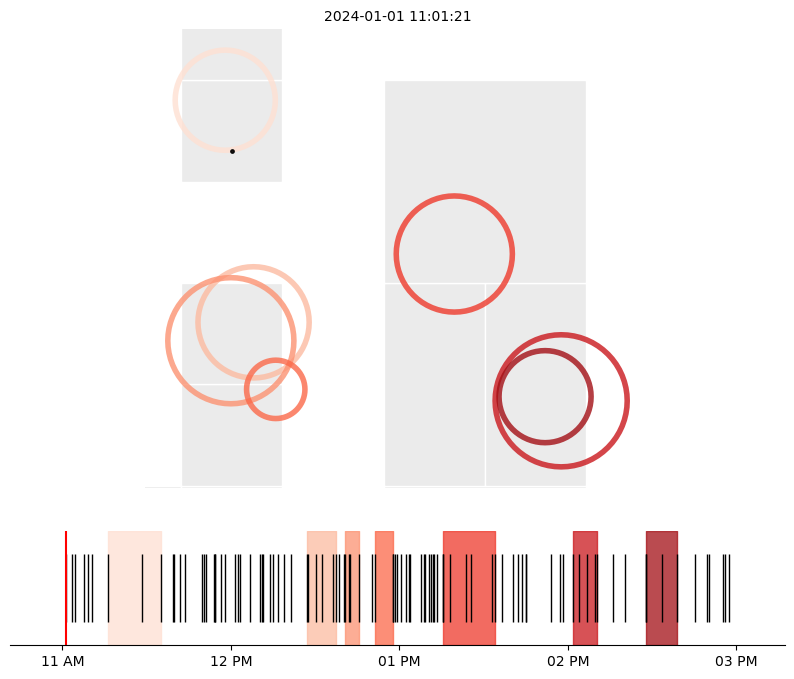

In [28]:
# run it & save GIF locally
from nomad.stop_detection.viz import animate_stop_dashboard

anim = animate_stop_dashboard(
    data=traj_anim,
    stops=stops_anim,
    save_path="lachesis_test.gif",
    traj_cols=tc_anim,
    show_path=True,
    base_geometry=city,
    base_geom_color="#ebebeb",
    base_geom_background="white"
)

print("animation saved")

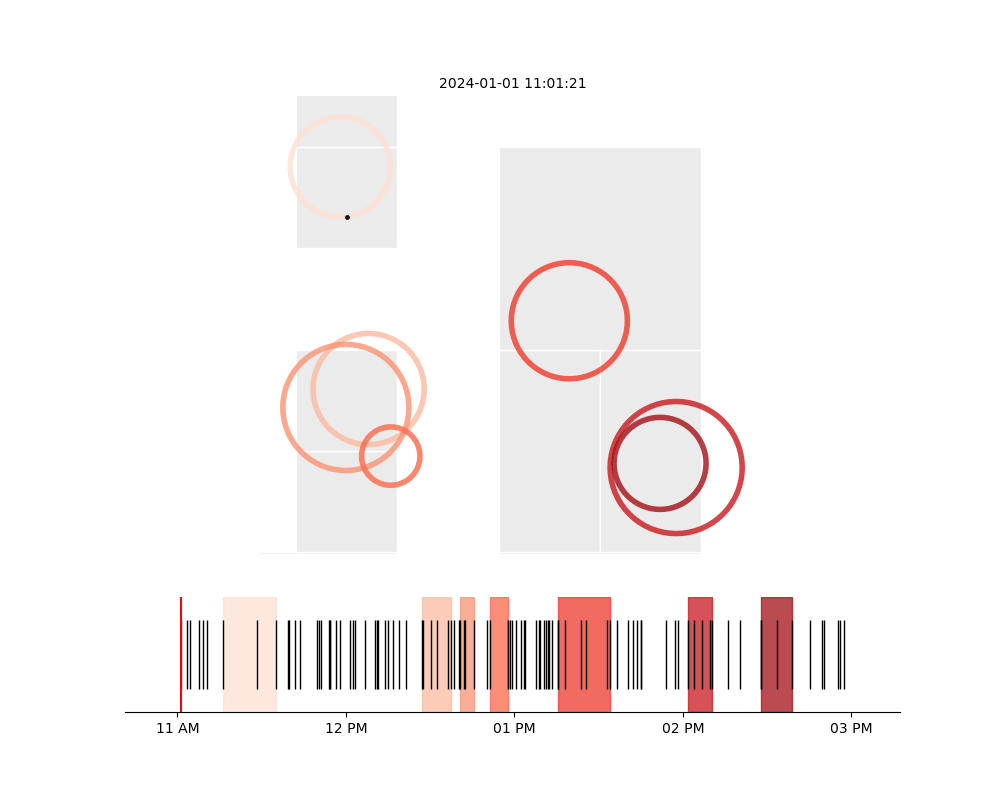

In [1]:
from IPython.display import Image
Image(filename="lachesis_test.gif")